<a href="https://colab.research.google.com/github/gohyongxuan/Reports/blob/main/Bayesian_Analysis_Log_Reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
try:
    import bambi as bmb
except ImportError:
    !{sys.executable} -m pip install --upgrade bambi
    import bambi as bmb
import pandas as pd
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss
from sklearn.metrics import log_loss
from sklearn.metrics import mean_absolute_error
import math
import arviz as az
import pytensor.tensor as at

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 2.3 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv('resale_flat_prices.csv')
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [ ]:
def aff(x):
    if x >= 600000:
        return 0
    else:
        return 1
def get_region(row):
    town = row["town"]
    if town in ['ANG MO KIO','BISHAN', 'BUKIT TIMAH', 'CENTRAL AREA', 'GEYLANG', 'KALLANG/WHAMPOA', 'TOA PAYOH']:
        return 6
    elif town in ['BUKIT MERAH', 'QUEENSTOWN', 'CLEMENTI']:
        return 5
    elif town in ['MARINE PARADE', 'BEDOK', 'PASIR RIS', 'TAMPINES']:
        return 4
    elif town in ['BUKIT BATOK', 'BUKIT PANJANG', 'CHOA CHU KANG', 'JURONG EAST', 'JURONG WEST']:
        return 1
    elif town in ['HOUGANG', 'PUNGGOL', 'SENGKANG', 'SERANGOON']:
        return 3
    elif town in ['SEMBAWANG', 'WOODLANDS', 'YISHUN']:
        return 2
    else:
        return None
df['year'] = df['month'].apply(lambda x: int(x.split('-')[0]))
df['year_sq'] = df['year'].apply(lambda x: x**2)
df['remaining_lease'] = df['remaining_lease'].apply(lambda x: int(x.split(' ')[0]))
df['storey_range'] = df['storey_range'].apply(lambda x: (int(x.split(' ')[0]) + int(x.split(' ')[2]))/2)
df['affordability'] = df['resale_price'].apply(aff)
df["region"] = df.apply(get_region, axis=1)
le = preprocessing.LabelEncoder()
df['flat_type'] = le.fit_transform(df['flat_type'])
df = df.drop(['block','street_name','lease_commence_date','town','flat_model','floor_area_sqm','month'],axis=1)
df.head(3)

,flat_type,storey_range,remaining_lease,resale_price,year,year_sq,affordability,region
0,1,11.0,61,232000.0,2017,4068289,1,6
1,2,2.0,60,250000.0,2017,4068289,1,6
2,2,2.0,62,262000.0,2017,4068289,1,6


In [ ]:
df.describe()

,flat_type,storey_range,remaining_lease,resale_price,year,year_sq,affordability,region
count,192149.000000,192149.000000,192149.00000,1.921490e+05,192149.000000,1.921490e+05,192149.000000,192149.000000
mean,3.121359,8.759333,74.06100,5.048896e+05,2020.650271,4.083032e+06,0.741362,3.214599
std,0.919658,5.938217,14.03203,1.761366e+05,2.220595,8.973533e+03,0.437887,1.692643
min,0.000000,2.000000,41.00000,1.400000e+05,2017.000000,4.068289e+06,0.000000,1.000000
25%,2.000000,5.000000,63.00000,3.750000e+05,2019.000000,4.076361e+06,0.000000,2.000000
50%,3.000000,8.000000,74.00000,4.750000e+05,2021.000000,4.084441e+06,1.000000,3.000000
75%,4.000000,11.000000,88.00000,6.010000e+05,2023.000000,4.092529e+06,1.000000,4.000000
max,6.000000,50.000000,97.00000,1.588000e+06,2024.000000,4.096576e+06,1.000000,6.000000


In [ ]:
numeric_features = df[['year', 'storey_range','remaining_lease']]

cols = numeric_features.columns

numeric_features.loc[:, cols] = preprocessing.scale(numeric_features.loc[:, cols])

data = pd.concat([numeric_features, df[['affordability', 'flat_type','region']]], axis=1)
data.head()

<ipython-input-4-04940a7e89e7>:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.6438298 -1.6438298 -1.6438298 ...  1.5084861  1.5084861  1.5084861]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  numeric_features.loc[:, cols] = preprocessing.scale(numeric_features.loc[:, cols])
<ipython-input-4-04940a7e89e7>:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.93080141 -1.00206713 -0.8595357  ... -0.8595357  -1.07333284
 -0.8595357 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  numeric_features.loc[:, cols] = preprocessing.scale(numeric_features.loc[:, cols])


,year,storey_range,remaining_lease,affordability,flat_type,region
0,-1.64383,0.377331,-0.930801,1,1,6
1,-1.64383,-1.138279,-1.002067,1,2,6
2,-1.64383,-1.138279,-0.859536,1,2,6
3,-1.64383,-0.633076,-0.859536,1,2,6
4,-1.64383,-1.138279,-0.859536,1,2,6


In [ ]:
X = data.drop(columns=['affordability'])
y = data['affordability']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test,y_test],axis=1)

In [ ]:
# func_sq = 'affordability ~ region + year + year_sq + flat_type + storey_range + remaining_lease'
func = 'affordability ~ region + year + flat_type + storey_range + remaining_lease'

In [ ]:
model_2 = bmb.Model(func, train_data, family='bernoulli')
idata_2 = model_2.fit(chains=4)

Output()

Output()

Output()

Output()

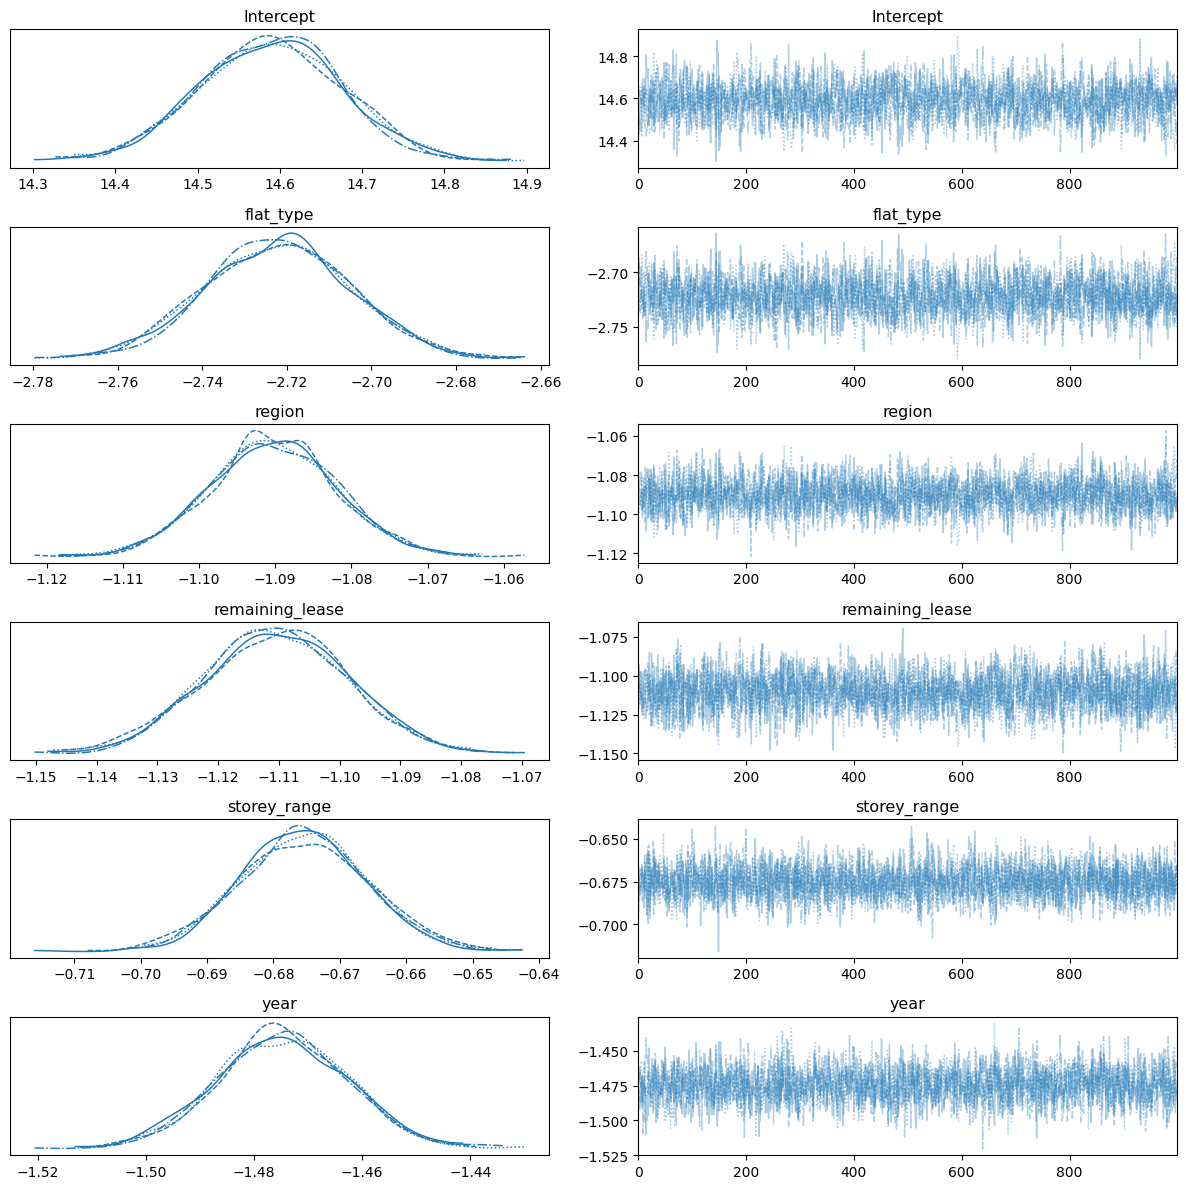

In [ ]:
az.plot_trace(idata_2)
plt.tight_layout()

In [ ]:
pm.summary(idata_2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,14.589,0.086,14.429,14.748,0.002,0.001,1840.0,2327.0,1.0
flat_type,-2.722,0.017,-2.753,-2.689,0.000,0.000,2140.0,2839.0,1.0
region,-1.090,0.008,-1.105,-1.074,0.000,0.000,2132.0,2492.0,1.0
remaining_lease,-1.111,0.012,-1.132,-1.088,0.000,0.000,2306.0,2590.0,1.0
storey_range,-0.675,0.009,-0.693,-0.658,0.000,0.000,3118.0,2829.0,1.0
year,-1.475,0.012,-1.498,-1.453,0.000,0.000,2326.0,2749.0,1.0


In [ ]:
intercept_samples = idata_2.posterior['Intercept'].values.flatten()
coef_samples_flat_type = idata_2.posterior['flat_type'].values.flatten()
coef_samples_remaining_lease = idata_2.posterior['remaining_lease'].values.flatten()
coef_samples_storey_range = idata_2.posterior['storey_range'].values.flatten()
coef_samples_year = idata_2.posterior['year'].values.flatten()
coef_samples_region = idata_2.posterior['region'].values.flatten()

In [ ]:
def logistic(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
predictions = []

for i in range(len(intercept_samples)):
    linear_pred = (
        intercept_samples[i] +
        coef_samples_flat_type[i] * X_test['flat_type'] +
        coef_samples_remaining_lease[i] * X_test['remaining_lease'] +
        coef_samples_storey_range[i] * X_test['storey_range'] +
        coef_samples_year[i] * X_test['year'] +
        coef_samples_region[i] * X_test['region']
    )

    predicted_prob = logistic(linear_pred)

    simulated_outcomes = np.random.binomial(1, predicted_prob)
    predictions.append(simulated_outcomes)

ppc_results = pd.DataFrame(predictions).T


In [ ]:
mean_ppc = ppc_results.mean(axis=1)
actuals = test_data['affordability'].values

In [ ]:
# ppc_comparison = pd.DataFrame({'Actual': actuals, 'Predicted_Mean': mean_ppc})
# ppc_comparison.plot(kind='bar')
# plt.title("PPC: Actual vs. Predicted")
# plt.show()

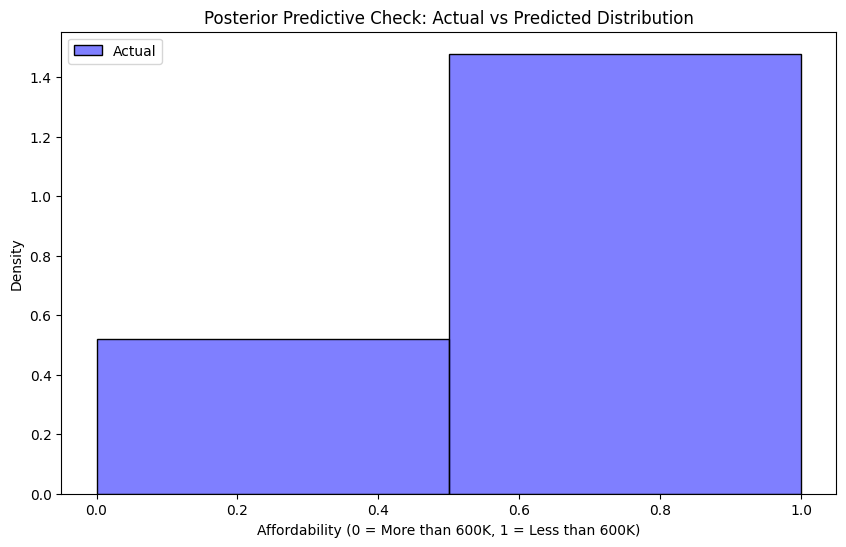

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(actuals, kde=False, color="blue", label="Actual", bins=2, stat="density", alpha=0.5)

plt.xlabel("Affordability (0 = More than 600K, 1 = Less than 600K)")
plt.ylabel("Density")
plt.legend()
plt.title("Posterior Predictive Check: Actual vs Predicted Distribution")
plt.show()

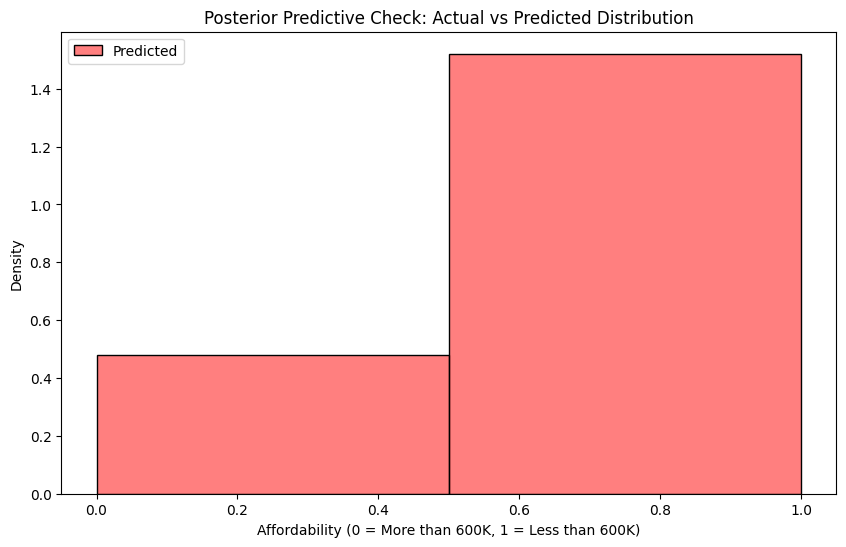

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(mean_ppc, kde=False, color="red", label="Predicted", bins=2, stat="density", alpha=0.5)

plt.xlabel("Affordability (0 = More than 600K, 1 = Less than 600K)")
plt.ylabel("Density")
plt.legend()
plt.title("Posterior Predictive Check: Actual vs Predicted Distribution")
plt.show()

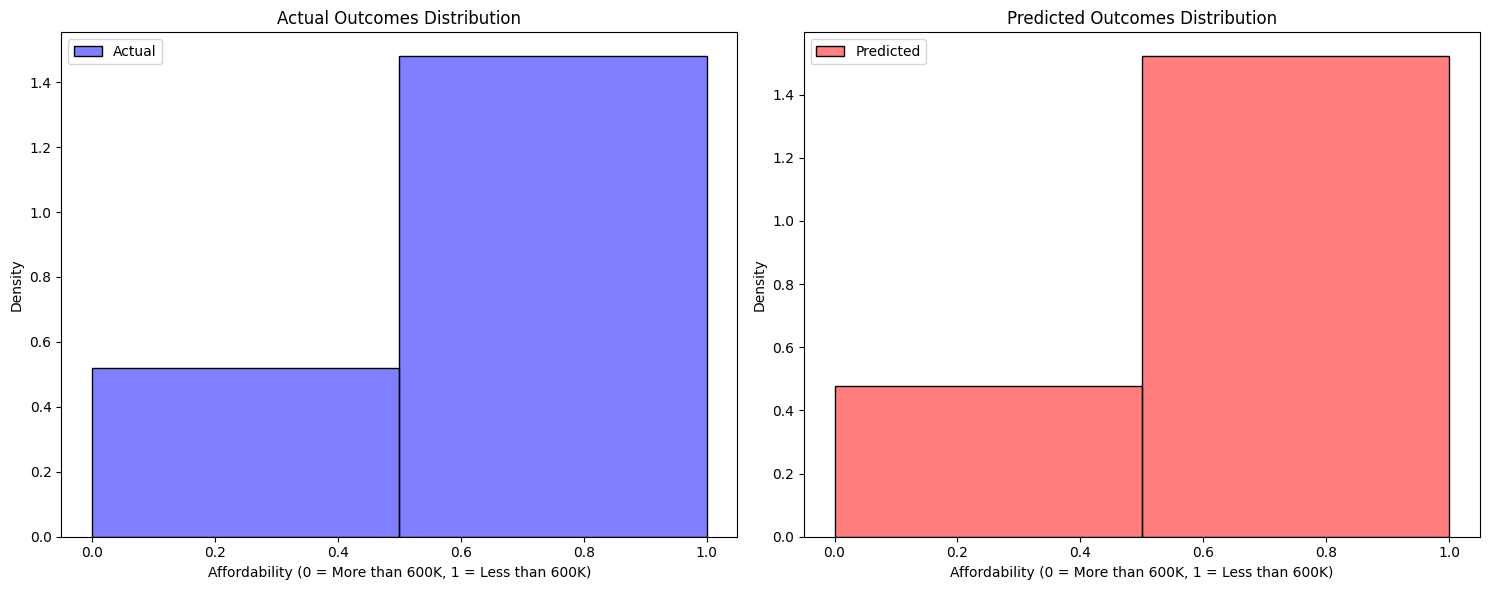

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(actuals, kde=False, color="blue", label="Actual", bins=2, stat="density", alpha=0.5, ax=axes[0])
axes[0].set_xlabel("Affordability (0 = More than 600K, 1 = Less than 600K)")
axes[0].set_ylabel("Density")
axes[0].set_title("Actual Outcomes Distribution")
axes[0].legend()

sns.histplot(mean_ppc, kde=False, color="red", label="Predicted", bins=2, stat="density", alpha=0.5, ax=axes[1])
axes[1].set_xlabel("Affordability (0 = More than 600K, 1 = Less than 600K)")
axes[1].set_ylabel("Density")
axes[1].set_title("Predicted Outcomes Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

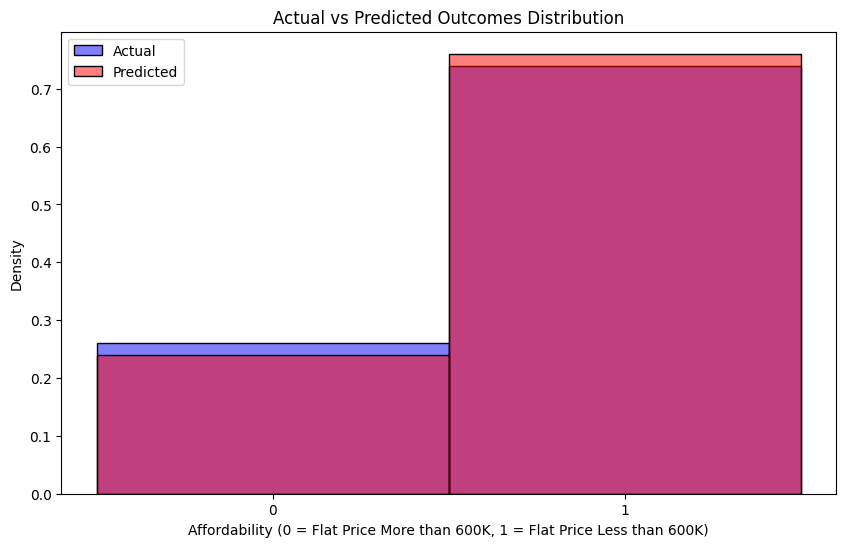

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(actuals, kde=False, color="blue", label="Actual", bins=[-0.5, 0.5, 1.5], stat="density", alpha=0.5, discrete=True)
sns.histplot(mean_ppc, kde=False, color="red", label="Predicted", bins=[-0.5, 0.5, 1.5], stat="density", alpha=0.5, discrete=True)

plt.xlabel("Affordability (0 = Flat Price More than 600K, 1 = Flat Price Less than 600K)")
plt.ylabel("Density")
plt.title("Actual vs Predicted Outcomes Distribution")
plt.legend()
plt.xticks([0, 1])
plt.show()

In [ ]:
logloss = log_loss(actuals, mean_ppc)
print("Log Loss:", logloss)

Log Loss: 0.26472189894249276
